In [17]:
#============================================================
# 1. نصب کتابخانه‌ها
# ============================================================
!pip -q install -U transformers accelerate scikit-learn sentencepiece pandas matplotlib seaborn ipywidgets

print("✅ Libraries installed successfully!")

✅ Libraries installed successfully!


In [18]:
# ============================================================
# 2. Imports + Settings
# ============================================================
import os
import re
import json
import html
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "HooshvareLab/bert-fa-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5

LABEL_MAPPING = {-3: 0, -2: 1, -1: 2, 0: 3, 1: 4, 2: 5, 3: 6}

CLASS_NAMES = [
    "خیلی منفی", "منفی", "کمی منفی", "خنثی",
    "کمی مثبت", "مثبت", "خیلی مثبت"
]

CLASS_NAMES_EN = [
    "Very Negative", "Negative", "Slightly Negative", "Neutral",
    "Slightly Positive", "Positive", "Very Positive"
]

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [19]:
# ============================================================
# 3. دریافت و بارگذاری دیتاست ParsiNLU
# ============================================================

import os
import json
import pandas as pd

REPO_PATH = "parsinlu"
BASE_PATH = "parsinlu/data/sentiment-analysis"

# اگر دیتاست وجود ندارد، دانلود شود
if not os.path.exists(REPO_PATH):
    !git clone -q https://github.com/persiannlp/parsinlu.git

print("Dataset path:", BASE_PATH)

# بررسی وجود پوشه
if not os.path.exists(BASE_PATH):
    raise FileNotFoundError(
        f"مسیر دیتاست پیدا نشد: {BASE_PATH}"
    )

# نمایش فایل‌های موجود
print("\nFiles in dataset:")
for file in os.listdir(BASE_PATH):
    print(" -", file)


# ------------------------------------------------------------
# تابع خواندن JSONL
# ------------------------------------------------------------

def load_jsonl(path):
    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line:
                rows.append(json.loads(line))

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# خواندن Train / Dev / Test
# ------------------------------------------------------------

train_path = os.path.join(BASE_PATH, "food_train.jsonl")
dev_path   = os.path.join(BASE_PATH, "food_dev.jsonl")
test_path  = os.path.join(BASE_PATH, "food_test.jsonl")

train_df = load_jsonl(train_path)
dev_df   = load_jsonl(dev_path)
test_df  = load_jsonl(test_path)


# ------------------------------------------------------------
# انتخاب ستون‌های مورد نیاز
# ------------------------------------------------------------

required_cols = ["review", "aspect", "label"]

for name, df in [
    ("Train", train_df),
    ("Dev", dev_df),
    ("Test", test_df)
]:
    missing = [col for col in required_cols if col not in df.columns]

    if missing:
        print(f"\n❌ ستون‌های موجود در {name}:")
        print(df.columns.tolist())

        raise ValueError(
            f"ستون‌های {missing} در دیتاست {name} وجود ندارند."
        )


train_df = train_df[required_cols].copy()
dev_df   = dev_df[required_cols].copy()
test_df  = test_df[required_cols].copy()


# ------------------------------------------------------------
# پاکسازی و تبدیل Label
# ------------------------------------------------------------

for df in [train_df, dev_df, test_df]:

    df["label"] = pd.to_numeric(
        df["label"],
        errors="coerce"
    )

    df.dropna(
        subset=["review", "aspect", "label"],
        inplace=True
    )

    df["label"] = df["label"].astype(int)


# ------------------------------------------------------------
# نمایش اطلاعات
# ------------------------------------------------------------

print("\n====================================")
print("       DATASET INFORMATION")
print("====================================")

print("Train:", len(train_df))
print("Dev  :", len(dev_df))
print("Test :", len(test_df))
print("Total:", len(train_df) + len(dev_df) + len(test_df))

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nSample:")
display(train_df.head())

Dataset path: parsinlu/data/sentiment-analysis

Files in dataset:
 - food_dev.jsonl
 - movie_train.jsonl
 - human_evaluation_movie.jsonl
 - movie.jsonl
 - food.jsonl
 - movie_test.jsonl
 - movie_dev.jsonl
 - ABSA_Dataset_train.jsonl
 - human_evaluation_movie_test.jsonl
 - food_train.jsonl
 - human_evaluation_food.jsonl
 - food_test.jsonl
 - human_evaluation_food_test.jsonl

       DATASET INFORMATION
Train: 10745
Dev  : 1330
Test : 1344
Total: 13419

Train columns:
['review', 'aspect', 'label']

Sample:


,review,aspect,label
0,دوستان حتما دقت کنید درقسمت فیله تکه های سبز ر...,طعم,-3
1,دوستان حتما دقت کنید درقسمت فیله تکه های سبز ر...,ارزش خرید,-3
2,دوستان حتما دقت کنید درقسمت فیله تکه های سبز ر...,ارسال,-3
3,دوستان حتما دقت کنید درقسمت فیله تکه های سبز ر...,بسته بندی,-3
4,دوستان حتما دقت کنید درقسمت فیله تکه های سبز ر...,ارزش غذایی,-2


In [20]:
# ============================================================
# 3-B. افزودن حوزه آرایشی و بهداشتی (دیتاست اولیه مصنوعی)
# ============================================================
import random
random.seed(42)

cosmetic_templates = [
('کرم خیلی خوب بود و بافت سبکی داشت', 'بافت', 2),
('این محصول اصلاً آبرسانی خوبی نداشت', 'آبرسانی', -2),
('رایحه محصول خوشایند و ملایم بود', 'رایحه', 2),
('بسته بندی هنگام تحویل آسیب دیده بود', 'بسته بندی', -2),
('قیمت محصول نسبت به کیفیت آن مناسب است', 'ارزش خرید', 2),
('اثرگذاری محصول ضعیف بود و نتیجه نگرفتم', 'اثرگذاری', -2),
('کیفیت محصول معمولی بود', 'کیفیت', 0),
('محصول باعث حساسیت پوستی شد', 'سازگاری پوستی', -3),
('از خرید این محصول راضی هستم', 'رضایت کلی', 3),
('محصول دیر به دستم رسید', 'ارسال', -1),
]

def make_cosmetic_df(n):
    rows = []
    for _ in range(n):
        text, aspect, label = random.choice(cosmetic_templates)
        rows.append({'review': text, 'aspect': aspect, 'label': label})
    return pd.DataFrame(rows)

cos_train = make_cosmetic_df(800)
cos_dev = make_cosmetic_df(160)
cos_test = make_cosmetic_df(160)

train_df = pd.concat([train_df, cos_train], ignore_index=True)
dev_df = pd.concat([dev_df, cos_dev], ignore_index=True)
test_df = pd.concat([test_df, cos_test], ignore_index=True)

print('نمونه‌های آرایشی و بهداشتی افزوده‌شده:')
print('Train:', len(cos_train), '| Dev:', len(cos_dev), '| Test:', len(cos_test))
print('تعداد نهایی Train/Dev/Test:', len(train_df), len(dev_df), len(test_df))


نمونه‌های آرایشی و بهداشتی افزوده‌شده:
Train: 800 | Dev: 160 | Test: 160
تعداد نهایی Train/Dev/Test: 11545 1490 1504


===== Label Distribution =====
label
-3    7540
-2     972
-1     810
 0     118
 1     946
 2     882
 3     277
Name: count, dtype: int64

===== Aspect Distribution =====
aspect
بسته بندی        1635
ارزش خرید        1621
کیفیت            1619
ارسال            1607
طعم              1535
ارزش غذایی       1535
کلی              1535
آبرسانی            85
رضایت کلی          85
سازگاری پوستی      75
بافت               73
اثرگذاری           72
رایحه              68
Name: count, dtype: int64

===== Review Length =====
Average: 83.52
Shortest: 22
Longest: 268


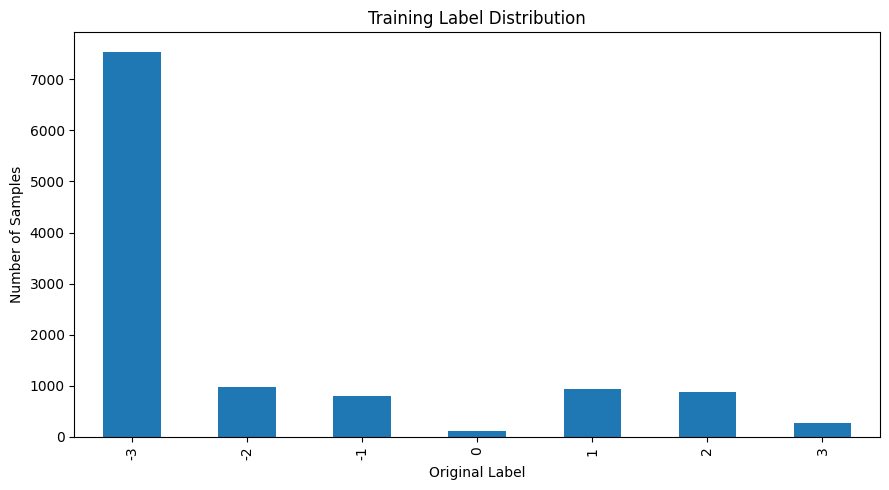


===== Label Mapping =====


,label,label_id
0,-3,0
4,-2,1
109,-1,2
13,0,3
21,1,4
22,2,5
111,3,6



===== Missing Label IDs =====
Train: 0
Dev  : 0
Test : 0

✅ EDA and Label Mapping completed successfully!


In [21]:
# ============================================================
# 4. EDA + Label Mapping
# ============================================================

print("===== Label Distribution =====")
print(train_df["label"].value_counts().sort_index())

print("\n===== Aspect Distribution =====")
print(train_df["aspect"].value_counts())

# ------------------------------------------------------------
# بررسی طول نظرات
# ------------------------------------------------------------

lengths = train_df["review"].astype(str).str.len()

print("\n===== Review Length =====")
print("Average:", round(lengths.mean(), 2))
print("Shortest:", lengths.min())
print("Longest:", lengths.max())


# ------------------------------------------------------------
# نمودار توزیع Label
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

train_df["label"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Training Label Distribution")
plt.xlabel("Original Label")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Label Mapping
# ------------------------------------------------------------

LABEL_MAPPING = {
    -3: 0,
    -2: 1,
    -1: 2,
     0: 3,
     1: 4,
     2: 5,
     3: 6
}


# ساخت ستون جدید label_id
train_df["label_id"] = train_df["label"].map(LABEL_MAPPING)
dev_df["label_id"] = dev_df["label"].map(LABEL_MAPPING)
test_df["label_id"] = test_df["label"].map(LABEL_MAPPING)


# ------------------------------------------------------------
# بررسی Mapping
# ------------------------------------------------------------

print("\n===== Label Mapping =====")

display(
    train_df[
        ["label", "label_id"]
    ]
    .drop_duplicates()
    .sort_values("label")
)


# ------------------------------------------------------------
# بررسی Labelهای نامعتبر
# ------------------------------------------------------------

print("\n===== Missing Label IDs =====")

print("Train:", train_df["label_id"].isna().sum())
print("Dev  :", dev_df["label_id"].isna().sum())
print("Test :", test_df["label_id"].isna().sum())


print("\n✅ EDA and Label Mapping completed successfully!")

In [22]:
# ============================================================
# 5. Tokenizer + Dataset
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class PersianABSA_Dataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        encoding = self.tokenizer(
            str(row["review"]),
            str(row["aspect"]),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(int(row["label_id"]), dtype=torch.long)
        }

train_dataset = PersianABSA_Dataset(train_df, tokenizer, MAX_LENGTH)
dev_dataset = PersianABSA_Dataset(dev_df, tokenizer, MAX_LENGTH)
test_dataset = PersianABSA_Dataset(test_df, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train:", len(train_dataset))
print("Dev  :", len(dev_dataset))
print("Test :", len(test_dataset))

Train: 11545
Dev  : 1490
Test : 1504


In [23]:
# ============================================================
# 6. Training / Evaluation Functions
# ============================================================
def evaluate_model(model, loader):
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(outputs.logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return {
        "accuracy": accuracy_score(true_labels, predictions),
        "macro_f1": f1_score(true_labels, predictions, average="macro", zero_division=0),
        "weighted_f1": f1_score(true_labels, predictions, average="weighted", zero_division=0),
        "predictions": np.array(predictions),
        "true_labels": np.array(true_labels)
    }


def train_model(model, train_loader, dev_loader, epochs, lr, loss_fn=None, save_path="best.pt"):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_f1 = -1
    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            if loss_fn is None:
                loss = CrossEntropyLoss()(outputs.logits, labels)
            else:
                loss = loss_fn(outputs.logits, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            bar.set_postfix(loss=f"{loss.item():.4f}")

        metrics = evaluate_model(model, dev_loader)
        avg_loss = total_loss / max(len(train_loader), 1)

        history.append({
            "epoch": epoch + 1,
            "loss": avg_loss,
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
            "weighted_f1": metrics["weighted_f1"]
        })

        print(
            f"Epoch {epoch+1} | Loss={avg_loss:.4f} | "
            f"Accuracy={metrics['accuracy']:.4f} | "
            f"Macro-F1={metrics['macro_f1']:.4f} | "
            f"Weighted-F1={metrics['weighted_f1']:.4f}"
        )

        if metrics["macro_f1"] > best_f1:
            best_f1 = metrics["macro_f1"]
            torch.save(model.state_dict(), save_path)
            print(f"⭐ Best model saved. Macro-F1={best_f1:.4f}")

    return pd.DataFrame(history), best_f1

In [24]:
# ============================================================
# 7. Baseline BERT
# ============================================================
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=7
)

baseline_history, baseline_best_f1 = train_model(
    baseline_model,
    train_loader,
    dev_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    save_path="best_baseline_bert.pt"
)

print("✅ Baseline training completed!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-fa-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	thos

Epoch 1/3:   0%|          | 0/722 [00:00<?, ?it/s]

Epoch 1 | Loss=0.5888 | Accuracy=0.8685 | Macro-F1=0.7358 | Weighted-F1=0.8648
⭐ Best model saved. Macro-F1=0.7358


Epoch 2/3:   0%|          | 0/722 [00:00<?, ?it/s]

Epoch 2 | Loss=0.3207 | Accuracy=0.8946 | Macro-F1=0.7806 | Weighted-F1=0.8903
⭐ Best model saved. Macro-F1=0.7806


Epoch 3/3:   0%|          | 0/722 [00:00<?, ?it/s]

Epoch 3 | Loss=0.2175 | Accuracy=0.8919 | Macro-F1=0.7699 | Weighted-F1=0.8888
✅ Baseline training completed!


In [25]:
# ============================================================
# 8. Class Weights + Weighted BERT
# ============================================================
train_labels = torch.tensor(
    train_df["label_id"].values,
    dtype=torch.long
)

class_counts = torch.bincount(
    train_labels,
    minlength=7
).float()

class_weights = len(train_labels) / (7 * class_counts)
class_weights = torch.clamp(class_weights, min=0.5, max=5.0)
class_weights = class_weights.to(device)

print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.cpu().tolist())

weighted_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=7
)

weighted_loss = CrossEntropyLoss(weight=class_weights)

weighted_history, weighted_best_f1 = train_model(
    weighted_model,
    train_loader,
    dev_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    loss_fn=weighted_loss,
    save_path="best_weighted_bert.pt"
)

print("✅ Weighted BERT training completed!")

Class counts: [7540.0, 972.0, 810.0, 118.0, 946.0, 882.0, 277.0]
Class weights: [0.5, 1.69679594039917, 2.0361552238464355, 5.0, 1.7434309720993042, 1.8699384927749634, 5.0]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-fa-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	thos

Epoch 1/3:   0%|          | 0/722 [00:00<?, ?it/s]

Epoch 1 | Loss=0.9096 | Accuracy=0.8664 | Macro-F1=0.7359 | Weighted-F1=0.8671
⭐ Best model saved. Macro-F1=0.7359


Epoch 2/3:   0%|          | 0/722 [00:00<?, ?it/s]

Epoch 2 | Loss=0.5232 | Accuracy=0.8906 | Macro-F1=0.7724 | Weighted-F1=0.8893
⭐ Best model saved. Macro-F1=0.7724


Epoch 3/3:   0%|          | 0/722 [00:00<?, ?it/s]

Epoch 3 | Loss=0.3698 | Accuracy=0.8893 | Macro-F1=0.7636 | Weighted-F1=0.8900
✅ Weighted BERT training completed!


,Model,Accuracy,Macro-F1,Weighted-F1
0,Baseline BERT,0.894631,0.780615,0.890327
1,BERT + Class Weight,0.890604,0.772437,0.889319


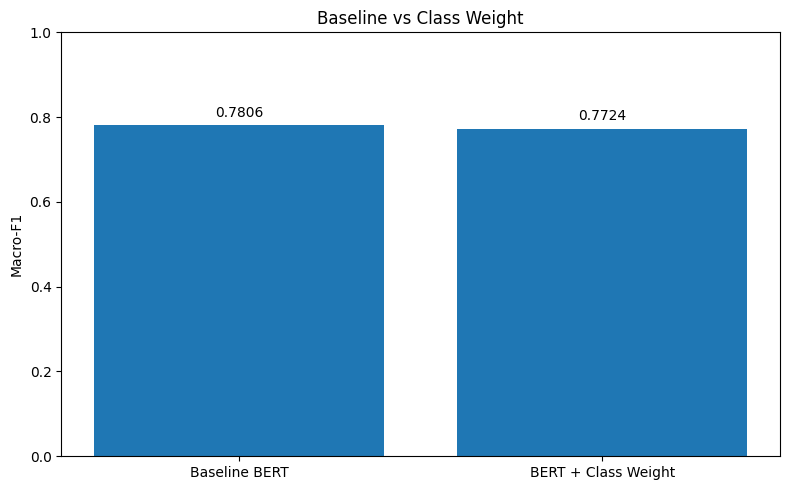

In [26]:
# ============================================================
# 9. Model Comparison
# ============================================================
baseline_model.load_state_dict(
    torch.load("best_baseline_bert.pt", map_location=device)
)
weighted_model.load_state_dict(
    torch.load("best_weighted_bert.pt", map_location=device)
)

baseline_metrics = evaluate_model(baseline_model, dev_loader)
weighted_metrics = evaluate_model(weighted_model, dev_loader)

comparison = pd.DataFrame([
    {
        "Model": "Baseline BERT",
        "Accuracy": baseline_metrics["accuracy"],
        "Macro-F1": baseline_metrics["macro_f1"],
        "Weighted-F1": baseline_metrics["weighted_f1"]
    },
    {
        "Model": "BERT + Class Weight",
        "Accuracy": weighted_metrics["accuracy"],
        "Macro-F1": weighted_metrics["macro_f1"],
        "Weighted-F1": weighted_metrics["weighted_f1"]
    }
])

display(comparison)

plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Macro-F1"])
plt.ylabel("Macro-F1")
plt.title("Baseline vs Class Weight")
plt.ylim(0, 1)

for i, value in enumerate(comparison["Macro-F1"]):
    plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 10. Final Test Evaluation
# ============================================================
weighted_model.load_state_dict(
    torch.load("best_weighted_bert.pt", map_location=device)
)
weighted_model.eval()

test_metrics = evaluate_model(weighted_model, test_loader)

test_predictions = test_metrics["predictions"]
test_true_labels = test_metrics["true_labels"]

print("====================================")
print("       FINAL TEST RESULTS")
print("====================================")
print(f"Accuracy    : {test_metrics['accuracy']:.4f}")
print(f"Macro-F1    : {test_metrics['macro_f1']:.4f}")
print(f"Weighted-F1 : {test_metrics['weighted_f1']:.4f}")

print("\n===== Classification Report =====")
print(
    classification_report(
        test_true_labels,
        test_predictions,
        labels=list(range(7)),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

       FINAL TEST RESULTS
Accuracy    : 0.8816
Macro-F1    : 0.7581
Weighted-F1 : 0.8815

===== Classification Report =====
              precision    recall  f1-score   support

   خیلی منفی     0.9595    0.9793    0.9693       967
        منفی     0.8230    0.6889    0.7500       135
    کمی منفی     0.5574    0.6667    0.6071       102
        خنثی     0.9500    0.7037    0.8085        27
    کمی مثبت     0.6772    0.7748    0.7227       111
        مثبت     0.8800    0.7333    0.8000       120
   خیلی مثبت     0.7143    0.5952    0.6494        42

    accuracy                         0.8816      1504
   macro avg     0.7945    0.7346    0.7581      1504
weighted avg     0.8858    0.8816    0.8815      1504



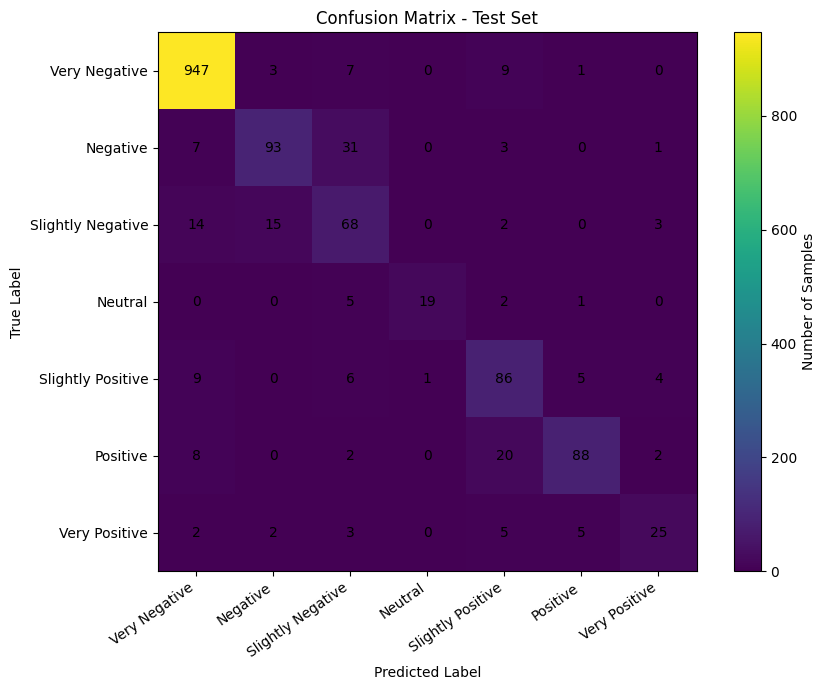

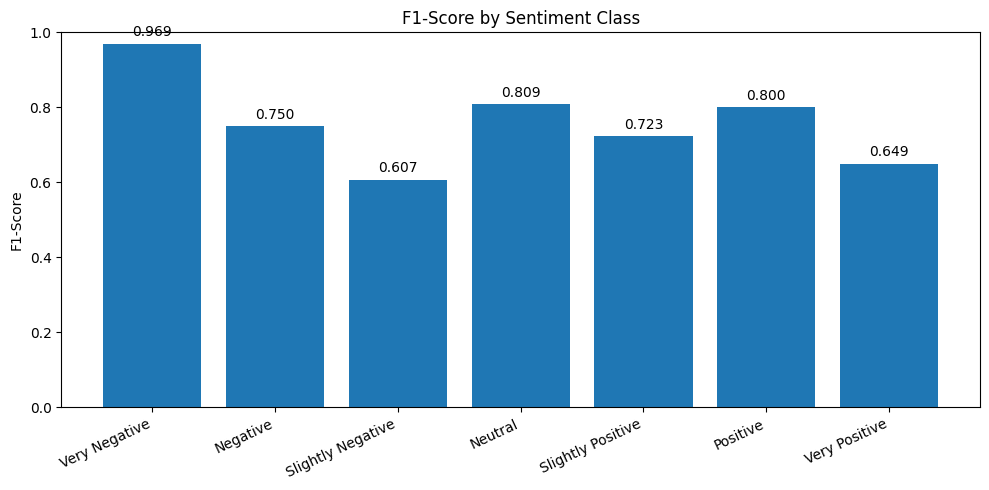

In [28]:
# ============================================================
# 11. Confusion Matrix + Per-Class F1
# ============================================================
cm = confusion_matrix(
    test_true_labels,
    test_predictions,
    labels=list(range(7))
)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(7), CLASS_NAMES_EN, rotation=35, ha="right")
plt.yticks(range(7), CLASS_NAMES_EN)

for i in range(7):
    for j in range(7):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(label="Number of Samples")
plt.tight_layout()
plt.show()

report = classification_report(
    test_true_labels,
    test_predictions,
    labels=list(range(7)),
    target_names=CLASS_NAMES_EN,
    output_dict=True,
    zero_division=0
)

f1_values = [report[name]["f1-score"] for name in CLASS_NAMES_EN]

plt.figure(figsize=(10, 5))
plt.bar(CLASS_NAMES_EN, f1_values)
plt.title("F1-Score by Sentiment Class")
plt.ylabel("F1-Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")

for i, value in enumerate(f1_values):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# 12. Save Final Model
# ============================================================
SAVE_PATH = "/content/final_bert_absa"
os.makedirs(SAVE_PATH, exist_ok=True)

weighted_model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

final_labels = {str(i): name for i, name in enumerate(CLASS_NAMES_EN)}

with open(
    os.path.join(SAVE_PATH, "label_mapping.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(final_labels, f, ensure_ascii=False, indent=4)

print("✅ Final model saved successfully!")
print("Path:", SAVE_PATH)
print("Files:", os.listdir(SAVE_PATH))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Final model saved successfully!
Path: /content/final_bert_absa
Files: ['model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'label_mapping.json', 'config.json']


In [30]:
# ============================================================
# 13. Prediction Functions (Food + Cosmetics, automatic domain)
# ============================================================
sentiment_labels = {
    0: "خیلی منفی", 1: "منفی", 2: "کمی منفی", 3: "خنثی",
    4: "کمی مثبت", 5: "مثبت", 6: "خیلی مثبت"
}

FOOD_ASPECTS = ["طعم", "ارزش خرید", "ارسال", "بسته بندی", "ارزش غذایی", "کیفیت", "کلی"]
COSMETIC_ASPECTS = ["سازگاری پوستی", "بافت", "رایحه", "ماندگاری", "اثرگذاری", "ترکیبات", "آبرسانی", "ارزش خرید", "ارسال", "بسته بندی", "کلی"]

DOMAIN_KEYWORDS = {
    "آرایشی و بهداشتی": ["کرم", "پوست", "مو", "شامپو", "ماسک", "عطر", "رایحه", "لوسیون", "ضدآفتاب", "آبرسان", "سرم", "لوازم آرایش", "بافت"],
    "غذا و نوشیدنی": ["غذا", "نوشیدنی", "طعم", "مزه", "رستوران", "برنج", "مرغ", "گوشت", "قهوه", "چای", "بسته بندی", "ارسال"]
}

ASPECT_KEYWORDS = {
    "طعم": ["طعم", "مزه", "خوشمزه", "شور", "شیرین"],
    "ارزش خرید": ["قیمت", "ارزش خرید", "گران", "ارزان"],
    "ارسال": ["ارسال", "تحویل", "دیر رسید", "پیک"],
    "بسته بندی": ["بسته بندی", "جعبه", "بسته‌بندی", "آسیب"],
    "ارزش غذایی": ["کالری", "ارزش غذایی", "پروتئین"],
    "کیفیت": ["کیفیت", "مرغوب"],
    "سازگاری پوستی": ["حساسیت", "سوزش", "پوست", "سازگاری"],
    "بافت": ["بافت", "چرب", "سبک", "سنگین"],
    "رایحه": ["رایحه", "بو", "عطر"],
    "ماندگاری": ["ماندگاری", "دوام"],
    "اثرگذاری": ["اثرگذاری", "نتیجه", "تأثیر"],
    "ترکیبات": ["ترکیبات", "مواد تشکیل دهنده"],
    "آبرسانی": ["آبرسان", "رطوبت", "خشکی"]
}

def detect_domain_auto(text):
    scores = {domain: sum(1 for word in words if word in text) for domain, words in DOMAIN_KEYWORDS.items()}
    return max(scores, key=scores.get) if max(scores.values()) > 0 else "غذا و نوشیدنی"

def get_aspects_for_domain(domain):
    return COSMETIC_ASPECTS if domain == "آرایشی و بهداشتی" else FOOD_ASPECTS

def model_probabilities(sentence, aspect):
    weighted_model.eval()
    inputs = tokenizer(sentence, aspect, return_tensors="pt", truncation=True,
                       padding=True, max_length=MAX_LENGTH)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        probs = torch.softmax(weighted_model(**inputs).logits, dim=1)[0]
    return probs.cpu().numpy()

def predict_sentiment(review, aspect):
    probs = model_probabilities(review, aspect)
    predicted_class = int(np.argmax(probs))
    return sentiment_labels[predicted_class], float(probs[predicted_class])

def split_sentences(text):
    text = re.sub(r"\s+", " ", str(text).strip())
    return [p.strip() for p in re.split(r"(?<=[.!؟?؛])\s+|\n+", text) if p.strip()]

def analyze_sentence(sentence):
    domain = detect_domain_auto(sentence)
    aspects = get_aspects_for_domain(domain)
    mentioned = [a for a in aspects if any(k in sentence for k in ASPECT_KEYWORDS.get(a, []))]
    selected_aspects = mentioned[:3] if mentioned else [aspects[-1]]
    results = []
    for aspect in selected_aspects:
        label, confidence = predict_sentiment(sentence, aspect)
        results.append({"aspect": aspect, "sentiment_class": list(sentiment_labels.keys())[list(sentiment_labels.values()).index(label)],
                        "confidence": confidence, "domain": domain})
    return results

def analyze_review(text):
    return [(sentence, analyze_sentence(sentence)) for sentence in split_sentences(text)]


In [31]:
# ============================================================
# داشبورد نهایی تحلیل احساسات و استخراج جنبه‌ها (ABSA)
# غذا و نوشیدنی + آرایشی و بهداشتی
#
# راهنمای اجرا:
# 1) ابتدا سلول‌های نصب کتابخانه، بارگذاری tokenizer و مدل‌ها را اجرا کنید.
# 2) متغیرهای زیر باید از قبل در نوت‌بوک وجود داشته باشند:
#    weighted_model, cosmetic_model, tokenizer, device
# 3) اگر نام مدل یا tokenizer شما متفاوت است، نام آن‌ها را اصلاح کنید.
# 4) این کد را در یک سلول مستقل در Google Colab اجرا کنید.
# 5) «سایر» در این نسخه حذف شده است.
# ============================================================

import html
import re
import numpy as np
import torch
import ipywidgets as widgets

from IPython.display import display, HTML, clear_output


# سازگاری با متغیرهای فایل اول
# در فایل اول مدل نهایی با نام weighted_model ذخیره شده است.
if "cosmetic_model" not in globals() and "weighted_model" in globals():
    cosmetic_model = weighted_model

# استفاده از همان نگاشت ۷ کلاسه مدل آموزش‌دیده فایل اول
if "sentiment_labels" in globals():
    COSMETIC_LABELS = dict(sentiment_labels)

# ============================================================
# 1) برچسب‌های صحیح مدل غذا
# ============================================================

FOOD_LABELS = {
    0: "خیلی منفی",
    1: "منفی",
    2: "کمی منفی",
    3: "خنثی",
    4: "کمی مثبت",
    5: "مثبت",
    6: "خیلی مثبت",
}


# ============================================================
# 2) برچسب‌های مدل آرایشی
# در صورت داشتن mapping متفاوت، این قسمت را تغییر دهید.
# ============================================================

COSMETIC_LABELS = {
    0: "خیلی منفی",
    1: "منفی",
    2: "خنثی",
    3: "مثبت",
    4: "خیلی مثبت",
}


# ============================================================
# 3) کلمات تشخیص حوزه محصول
# ============================================================

DOMAIN_KEYWORDS = {
    "غذا و نوشیدنی": [
        "غذا", "غذای", "رستوران", "پیتزا", "برگر", "ساندویچ",
        "کباب", "مرغ", "گوشت", "ماهی", "برنج", "چلو",
        "خورشت", "نوشیدنی", "نوشابه", "آبمیوه", "قهوه",
        "چای", "شکلات", "بیسکویت", "چیپس", "تنقلات",
        "طعم", "مزه", "صبحانه", "ناهار", "شام"
    ],
    "آرایشی و بهداشتی": [
        "کرم", "پوست", "مو", "شامپو", "ضدآفتاب", "ضد آفتاب",
        "سرم", "تونر", "مرطوب کننده", "مرطوب‌کننده", "رژ لب",
        "رژلب", "ریمل", "عطر", "ادکلن", "لوسیون", "اسکراب",
        "ضد جوش", "ضدجوش", "آرایشی", "بهداشتی", "ماسک صورت",
        "پاک‌کننده", "پاک کننده"
    ],
}


# ============================================================
# 4) جنبه‌های غذا
# ============================================================

FOOD_ASPECT_KEYWORDS = {
    "طعم": [
        "طعم", "مزه", "خوشمزه", "شور", "شیرین", "تلخ",
        "ترش", "بی‌مزه", "بدمزه"
    ],
    "ارزش خرید": [
        "قیمت", "گران", "گرون", "ارزان", "ارزون",
        "ارزش خرید", "صرفه"
    ],
    "ارسال": [
        "ارسال", "تحویل", "پیک", "دیر رسید", "زمان ارسال"
    ],
    "بسته‌بندی": [
        "بسته بندی", "بسته‌بندی", "بسته", "جعبه", "ظرف"
    ],
    "ارزش غذایی": [
        "ارزش غذایی", "کالری", "سالم", "رژیمی", "ویتامین"
    ],
    "کیفیت": [
        "کیفیت", "تازه", "تازگی", "مواد اولیه"
    ],
}


# ============================================================
# 5) جنبه‌های آرایشی و بهداشتی
# ============================================================

COSMETIC_ASPECT_KEYWORDS = {
    "بافت": [
        "بافت", "سبک", "سنگین", "چسبناک", "چرب",
        "خشک", "نرم", "روان"
    ],
    "احساس روی پوست": [
        "پوستم", "روی پوست", "حس", "سوزش", "جوش", "حساسیت"
    ],
    "ماندگاری": [
        "ماندگاری", "ماندگار", "دوام", "موندگاری", "موندگار"
    ],
    "قیمت": [
        "قیمت", "گران", "گرون", "ارزان", "ارزون", "ارزش خرید"
    ],
    "رایحه": [
        "بو", "بوی", "رایحه", "خوشبو", "بدبو", "عطر"
    ],
    "اثرگذاری": [
        "اثر", "اثرگذاری", "جواب داد", "نتیجه",
        "موثر", "تاثیر", "تأثیر"
    ],
    "رنگ و پوشش": [
        "رنگ", "پوشش", "کاور", "پوشانندگی", "کاوردهی"
    ],
    "بسته‌بندی": [
        "بسته بندی", "بسته‌بندی", "جعبه", "ظرف", "بسته"
    ],
    "کیفیت": [
        "کیفیت"
    ],
}


# ============================================================
# 6) توابع کمکی
# ============================================================

def normalize_text(text):
    """یکسان‌سازی ساده حروف فارسی و فاصله‌ها."""
    text = str(text).strip().lower()
    text = text.replace("ي", "ی").replace("ى", "ی")
    text = text.replace("ك", "ک")
    text = text.replace("\u200c", " ")
    text = re.sub(r"\s+", " ", text)
    return text


def detect_domain_final(text):
    text = normalize_text(text)

    scores = {}
    for domain, keywords in DOMAIN_KEYWORDS.items():
        scores[domain] = sum(
            1 for keyword in keywords
            if normalize_text(keyword) in text
        )

    best_domain = max(scores, key=scores.get)
    total = sum(scores.values())

    if scores[best_domain] == 0:
        return None, 0.0

    return best_domain, scores[best_domain] / total


def detect_aspects_final(text, domain):
    text = normalize_text(text)

    source = (
        FOOD_ASPECT_KEYWORDS
        if domain == "غذا و نوشیدنی"
        else COSMETIC_ASPECT_KEYWORDS
    )

    found = []
    for aspect, keywords in source.items():
        if any(normalize_text(keyword) in text for keyword in keywords):
            found.append(aspect)

    # اگر جنبه مشخصی در متن پیدا نشد، تحلیل کلی انجام می‌شود.
    return found if found else ["کلی"]


def split_sentences_final(text):
    parts = re.split(r"[.!؟?؛\n]+", str(text))
    return [part.strip() for part in parts if part.strip()]


def sentiment_type(sentiment):
    if "مثبت" in sentiment:
        return "مثبت"
    if "منفی" in sentiment:
        return "منفی"
    return "خنثی"


def sentiment_color(sentiment):
    kind = sentiment_type(sentiment)
    if kind == "مثبت":
        return "#16A34A"
    if kind == "منفی":
        return "#E5484D"
    return "#64748B"


def sentiment_score(sentiment):
    return {
        "خیلی منفی": -2,
        "منفی": -1,
        "کمی منفی": -0.5,
        "خنثی": 0,
        "کمی مثبت": 0.5,
        "مثبت": 1,
        "خیلی مثبت": 2,
    }.get(sentiment, 0)


def get_model_device():
    return device if "device" in globals() else torch.device("cpu")


def get_max_length():
    return int(MAX_LENGTH) if "MAX_LENGTH" in globals() else 128


# ============================================================
# 7) پیش‌بینی مدل غذا
# نکته: برای مدل غذا، review و aspect به‌صورت جفت وارد tokenizer می‌شوند.
# ============================================================

def predict_food_final(sentence, aspect):
    if "weighted_model" not in globals():
        raise NameError(
            "متغیر weighted_model پیدا نشد. ابتدا مدل غذا را بارگذاری کنید."
        )

    if "tokenizer" not in globals():
        raise NameError(
            "متغیر tokenizer پیدا نشد. ابتدا tokenizer را اجرا کنید."
        )

    model = weighted_model
    model.eval()

    current_device = get_model_device()

    encoded = tokenizer(
        str(sentence),
        str(aspect),
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=get_max_length(),
    )

    encoded = {
        key: value.to(current_device)
        for key, value in encoded.items()
    }

    with torch.no_grad():
        logits = model(**encoded).logits
        probabilities = torch.softmax(logits, dim=-1)[0]

    probabilities = probabilities.detach().cpu().numpy()
    predicted_id = int(np.argmax(probabilities))
    confidence = float(probabilities[predicted_id])

    sentiment = FOOD_LABELS.get(
        predicted_id,
        f"برچسب {predicted_id}"
    )

    return sentiment, confidence


# ============================================================
# 8) پیش‌بینی مدل آرایشی
# ============================================================

def predict_cosmetic_final(sentence, aspect=None):
    if "cosmetic_model" not in globals():
        raise NameError(
            "متغیر cosmetic_model پیدا نشد. ابتدا مدل آرایشی را بارگذاری کنید."
        )

    if "tokenizer" not in globals():
        raise NameError(
            "متغیر tokenizer پیدا نشد. ابتدا tokenizer را اجرا کنید."
        )

    model = cosmetic_model
    model.eval()

    current_device = get_model_device()

    encoded = tokenizer(
        str(sentence),
        truncation=True,
        padding="max_length",
        max_length=get_max_length(),
        return_tensors="pt",
    )

    encoded = {
        key: value.to(current_device)
        for key, value in encoded.items()
    }

    with torch.no_grad():
        logits = model(**encoded).logits
        probabilities = torch.softmax(logits, dim=-1)[0]

    probabilities = probabilities.detach().cpu().numpy()
    predicted_id = int(np.argmax(probabilities))
    confidence = float(probabilities[predicted_id])

    sentiment = COSMETIC_LABELS.get(
        predicted_id,
        f"برچسب {predicted_id}"
    )

    return sentiment, confidence


# ============================================================
# 9) CSS رابط کاربری
# ============================================================

display(HTML("""
<style>
.absa-wrapper {
    direction: rtl;
    font-family: Tahoma, Arial, sans-serif;
    background: #F8F7FC;
    border: 1px solid #E4DDF2;
    border-radius: 22px;
    padding: 24px;
    box-sizing: border-box;
}

.absa-title {
    text-align: center;
    color: #46318B;
    font-size: 25px;
    font-weight: 800;
    margin-bottom: 8px;
}

.absa-subtitle {
    text-align: center;
    color: #777;
    font-size: 13px;
    margin-bottom: 20px;
}

.absa-card {
    direction: rtl;
    background: white;
    border: 1px solid #E4DEF0;
    border-radius: 17px;
    padding: 18px;
    margin-top: 15px;
    box-shadow: 0 5px 18px rgba(60,40,100,.06);
}

.absa-label {
    color: #46318B;
    font-weight: 700;
    font-size: 15px;
    margin-bottom: 9px;
}

.absa-summary {
    display: flex;
    flex-wrap: wrap;
    gap: 12px;
}

.absa-summary-box {
    flex: 1;
    min-width: 165px;
    background: #FAF8FF;
    border: 1px solid #E8E1F5;
    border-radius: 14px;
    padding: 15px;
    text-align: center;
}

.absa-small {
    color: #777;
    font-size: 12px;
    margin-bottom: 7px;
}

.absa-value {
    color: #46318B;
    font-size: 18px;
    font-weight: 800;
}

.absa-table {
    width: 100%;
    border-collapse: collapse;
    font-size: 13px;
}

.absa-table th {
    background: #F0EBFA;
    color: #46318B;
    padding: 11px;
    border: 1px solid #DED7EB;
}

.absa-table td {
    padding: 11px;
    border: 1px solid #E5E1EA;
    text-align: center;
}

.absa-chart-container {
    display: flex;
    flex-wrap: wrap;
    gap: 15px;
    margin-top: 15px;
}

.absa-chart {
    flex: 1;
    min-width: 300px;
    background: white;
    border: 1px solid #E4DEF0;
    border-radius: 17px;
    padding: 18px;
}

.absa-bar {
    display: flex;
    align-items: center;
    gap: 10px;
    margin: 16px 0;
}

.absa-bar-label {
    width: 65px;
    font-weight: 700;
    color: #475569;
}

.absa-bar-bg {
    flex: 1;
    height: 18px;
    background: #EDF0F4;
    border-radius: 10px;
    overflow: hidden;
}

.absa-bar-fill {
    height: 100%;
    border-radius: 10px;
}

.absa-percent {
    width: 45px;
    font-weight: 700;
    color: #475569;
}
</style>
"""))


# ============================================================
# 10) نمودار میله‌ای HTML
# ============================================================

def create_bar_chart_final(counts):
    total = sum(counts.values())
    if total == 0:
        return "<p>داده‌ای برای نمایش وجود ندارد.</p>"

    data = [
        ("مثبت", counts.get("مثبت", 0), "#16A34A"),
        ("منفی", counts.get("منفی", 0), "#E5484D"),
        ("خنثی", counts.get("خنثی", 0), "#94A3B8"),
    ]

    result = ""
    for label, value, color in data:
        percentage = value / total * 100
        result += f"""
        <div class="absa-bar">
            <div class="absa-bar-label">{label}</div>
            <div class="absa-bar-bg">
                <div class="absa-bar-fill"
                     style="width:{percentage:.1f}%;background:{color};">
                </div>
            </div>
            <div class="absa-percent">{percentage:.0f}%</div>
        </div>
        """

    return result


# ============================================================
# 11) نمودار حلقه‌ای HTML
# ============================================================

def create_donut_chart_final(counts):
    total = sum(counts.values())
    if total == 0:
        return "<p>داده‌ای برای نمایش وجود ندارد.</p>"

    positive = counts.get("مثبت", 0) / total * 100
    negative = counts.get("منفی", 0) / total * 100
    neutral = counts.get("خنثی", 0) / total * 100

    end_positive = positive
    end_negative = positive + negative

    dominant = max(
        ["مثبت", "منفی", "خنثی"],
        key=lambda item: counts.get(item, 0)
    )

    dominant_percent = counts.get(dominant, 0) / total * 100

    return f"""
    <div style="
        display:flex;
        align-items:center;
        justify-content:center;
        gap:28px;
        flex-wrap:wrap;
        direction:rtl;
    ">
        <div style="
            width:155px;
            height:155px;
            border-radius:50%;
            background:conic-gradient(
                #16A34A 0% {end_positive:.1f}%,
                #E5484D {end_positive:.1f}% {end_negative:.1f}%,
                #94A3B8 {end_negative:.1f}% 100%
            );
            display:flex;
            align-items:center;
            justify-content:center;
        ">
            <div style="
                width:103px;
                height:103px;
                border-radius:50%;
                background:white;
                display:flex;
                flex-direction:column;
                align-items:center;
                justify-content:center;
            ">
                <div style="
                    font-size:23px;
                    font-weight:800;
                    color:#334155;
                ">
                    {dominant_percent:.0f}%
                </div>
                <div style="font-size:12px;color:#64748B;">
                    {html.escape(dominant)}
                </div>
            </div>
        </div>

        <div style="line-height:2.4;font-size:13px;color:#475569;">
            <div><span style="color:#16A34A">●</span> مثبت: {positive:.0f}%</div>
            <div><span style="color:#E5484D">●</span> منفی: {negative:.0f}%</div>
            <div><span style="color:#94A3B8">●</span> خنثی: {neutral:.0f}%</div>
        </div>
    </div>
    """


# ============================================================
# 12) ساخت رابط ورودی
# ============================================================

text_box_final = widgets.Textarea(
    placeholder=(
        "مثلاً: این کرم بافت سبکی دارد و روی پوست حس خوبی ایجاد می‌کند، "
        "اما ماندگاری آن کم است."
    ),
    layout=widgets.Layout(
        width="100%",
        height="125px"
    )
)

analyze_button_final = widgets.Button(
    description="🔍 تحلیل نظر",
    button_style="primary",
    layout=widgets.Layout(
        width="190px",
        height="44px"
    )
)

output_final = widgets.Output()


# ============================================================
# 13) تابع اصلی تحلیل
# ============================================================

def on_analyze_final(_):
    with output_final:
        clear_output(wait=True)

        text = text_box_final.value.strip()

        if not text:
            display(HTML("""
            <div class="absa-card"
                 style="text-align:center;color:#D32F2F;">
                لطفاً متن نظر را وارد کنید.
            </div>
            """))
            return

        try:
            domain, domain_confidence = detect_domain_final(text)

            if domain is None:
                display(HTML("""
                <div class="absa-card"
                     style="
                     text-align:center;
                     color:#9A6700;
                     background:#FFF9E8;
                     ">
                    حوزه محصول تشخیص داده نشد.
                    <br><br>
                    لطفاً درباره غذا و نوشیدنی یا محصولات آرایشی و
                    بهداشتی بنویسید.
                </div>
                """))
                return

            sentences = split_sentences_final(text)
            results = []

            for sentence in sentences:
                aspects = detect_aspects_final(sentence, domain)

                for aspect in aspects:
                    if domain == "غذا و نوشیدنی":
                        sentiment, confidence = predict_food_final(
                            sentence,
                            aspect
                        )
                    else:
                        sentiment, confidence = predict_cosmetic_final(
                            sentence,
                            aspect
                        )

                    results.append({
                        "sentence": sentence,
                        "aspect": aspect,
                        "sentiment": sentiment,
                        "confidence": confidence,
                    })

            if not results:
                display(HTML("""
                <div class="absa-card">
                    نتیجه‌ای برای نمایش پیدا نشد.
                </div>
                """))
                return

            scores = [
                sentiment_score(item["sentiment"])
                for item in results
            ]

            mean_score = sum(scores) / len(scores)

            if mean_score > 0.2:
                overall = "مثبت"
            elif mean_score < -0.2:
                overall = "منفی"
            else:
                overall = "خنثی"

            counts = {
                "مثبت": 0,
                "منفی": 0,
                "خنثی": 0,
            }

            for item in results:
                counts[sentiment_type(item["sentiment"])] += 1

            average_confidence = sum(
                item["confidence"] for item in results
            ) / len(results)

            display(HTML(f"""
            <div class="absa-card">
                <div class="absa-label" style="font-size:18px;">
                    📊 نتیجه تحلیل نظر
                </div>

                <div class="absa-summary">
                    <div class="absa-summary-box">
                        <div class="absa-small">حوزه تشخیص داده‌شده</div>
                        <div class="absa-value">
                            {html.escape(domain)}
                        </div>
                    </div>

                    <div class="absa-summary-box">
                        <div class="absa-small">احساس کلی</div>
                        <div class="absa-value"
                             style="color:{sentiment_color(overall)};">
                            {html.escape(overall)}
                        </div>
                    </div>

                    <div class="absa-summary-box">
                        <div class="absa-small">تعداد نتایج</div>
                        <div class="absa-value">{len(results)}</div>
                    </div>

                    <div class="absa-summary-box">
                        <div class="absa-small">اطمینان میانگین مدل</div>
                        <div class="absa-value">
                            {average_confidence:.0%}
                        </div>
                    </div>
                </div>
            </div>
            """))

            rows = ""

            for index, item in enumerate(results, start=1):
                color = sentiment_color(item["sentiment"])

                rows += f"""
                <tr>
                    <td>{index}</td>
                    <td>{html.escape(item["sentence"])}</td>
                    <td>{html.escape(item["aspect"])}</td>
                    <td style="color:{color};font-weight:800;">
                        {html.escape(item["sentiment"])}
                    </td>
                    <td>{item["confidence"]:.0%}</td>
                </tr>
                """

            display(HTML(f"""
            <div class="absa-card">
                <div class="absa-label" style="font-size:18px;">
                    📋 نتایج استخراج جنبه‌ها
                </div>

                <table class="absa-table">
                    <thead>
                        <tr>
                            <th>ردیف</th>
                            <th>جمله</th>
                            <th>جنبه (Aspect)</th>
                            <th>احساس</th>
                            <th>اطمینان</th>
                        </tr>
                    </thead>
                    <tbody>{rows}</tbody>
                </table>
            </div>
            """))

            display(HTML(f"""
            <div class="absa-chart-container">
                <div class="absa-chart">
                    <div class="absa-label">
                        📈 توزیع احساسات در جنبه‌ها
                    </div>
                    {create_bar_chart_final(counts)}
                </div>

                <div class="absa-chart">
                    <div class="absa-label">
                        ⭕ نتیجه کلی احساسات
                    </div>
                    {create_donut_chart_final(counts)}
                </div>
            </div>
            """))

        except Exception as error:
            display(HTML(f"""
            <div class="absa-card"
                 style="background:#FFF1F2;color:#B91C1C;">
                <b>خطا در اجرای تحلیل:</b>
                <br><br>
                {html.escape(str(error))}
                <br><br>
                <small>
                    بررسی کنید که مدل‌ها، tokenizer، device و MAX_LENGTH
                    در سلول‌های قبلی تعریف شده باشند.
                </small>
            </div>
            """))


# ============================================================
# 14) اتصال دکمه و نمایش نهایی
# ============================================================

analyze_button_final.on_click(on_analyze_final)

display(HTML("""
<div class="absa-wrapper">
    <div class="absa-title">
        تحلیل احساسات و استخراج جنبه‌های مهم (ABSA)
    </div>

    <div class="absa-subtitle">
        متن نظر خود را وارد کنید تا حوزه محصول، جنبه‌ها و احساس
        مربوط به آن‌ها شناسایی شود.
    </div>
</div>
"""))

display(widgets.VBox([
    widgets.HTML("""
    <div class="absa-card">
        <div class="absa-label">متن نظر کاربر</div>
    </div>
    """),
    text_box_final,
    analyze_button_final,
    output_final
], layout=widgets.Layout(width="100%")))
